# Correlation
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* Shayan Maleki

*SID:* 810102515

The objective of this notebook is to understand the concept of correlation.


In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

## Calculate Correlation
complete `correlation` function that calculate the correlation matrix of a data fram.

**Note:** you are not allowed to use `pandas.core.frame.DataFrame.corr()` method

    as we know the correlation is calculated by this formula: Cov(x,y)/sqrt(x)sqrt(y) 
    if i am correct each col and represent the x and y so what i did was i itereted over these and calculated the correlation of the X and Y each time and added it into my correlation matrix

In [72]:
def correlation(data: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the correlation matrix from a given dataset.

    Args:
        data (pandas.core.frame.DataFrame): The dataset, where each row represents an observation and each column represents a feature.

    Returns:
        correlation_matrix (pandas.core.frame.DataFrame): The correlation matrix.
    """
    ######################  TODO  ########################
    numeric_data = data.select_dtypes(include=[np.number]) 
    columns = numeric_data.columns
    correlationMatrix = np.zeros((len(columns), len(columns)))
    for i,col1 in enumerate(columns): 
        for j,col2 in enumerate(columns):
            X = data[col1] 
            Y = data[col2]
            meanX=np.mean(X)
            meanY=np.mean(Y)
            meanXY=np.mean(X*Y)
            varX=np.var(X)
            varY=np.var(Y)
            Cov = meanXY-meanX*meanY
            theCorrelation=Cov/(np.sqrt(varX)*np.sqrt(varY))
            correlationMatrix[i,j]=theCorrelation
    return correlationMatrix
            
    ######################  TODO  ########################

### Convert to Datetime and Extract Features

In [73]:
######################  TODO  ########################
energyCsv = pd.read_csv('data/energy.csv')
energyCsv['Datetime'] = pd.to_datetime(energyCsv['Datetime'])
######################  TODO  ########################

<h2>Extracting the year month hour from our datetime:</h2>

In [74]:
energyCsv['Year'] = energyCsv['Datetime'].dt.year
energyCsv['Month'] = energyCsv['Datetime'].dt.month
energyCsv['Hour'] = energyCsv['Datetime'].dt.hour

### Plot Energy Usage Over Years

<Axes: xlabel='Year', ylabel='AEP_MW'>

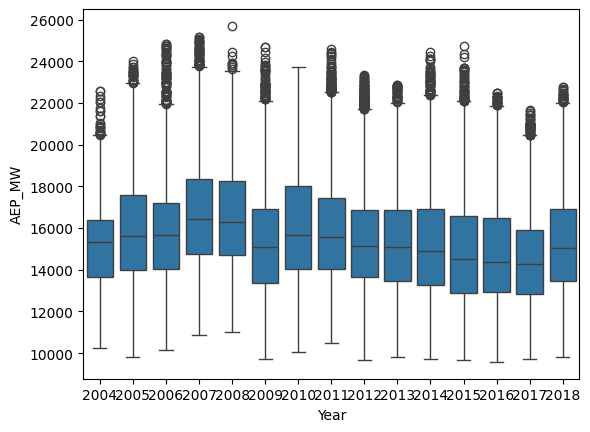

In [75]:
######################  TODO  ########################
sns.boxplot(x='Year', y='AEP_MW', data=energyCsv)
######################  TODO  ########################

### Analyze Energy Usage Over Years

    when comparing the 2004 and 2005 boxplot we can see that the 2005s box is bigger than the 2004s so we can assume that the 2005 has higher variance than 2004.
    what i am going to do below is to find the data frames with the year=2005 and year =2004 then calculate their variance.

In [76]:
######################  TODO  ########################
######################  TODO  ########################
y2005dataFrame=list()
y2004dataFrame=list()
for i,row in energyCsv.iterrows():
    if row['Year']==2005:
        y2005dataFrame.append(row)
    elif row['Year']==2004:
        y2004dataFrame.append(row)
y2005dataFrame = pd.DataFrame(y2005dataFrame)
y2004dataFrame = pd.DataFrame(y2004dataFrame)
y2005PowerUsage=y2005dataFrame['AEP_MW']
y2004PowerUsage=y2004dataFrame['AEP_MW']
y2005var=np.var(y2005PowerUsage)
y2004var=np.var(y2004PowerUsage)
print ('y2005var is ',y2005var)   
print ('y2004var is ',y2004var)       

######################  TODO  ########################
######################  TODO  ########################

y2005var is  6608761.862442252
y2004var is  4310599.722768778


    as we can see the 2005 has a hifher variance.

### Plot Energy Usage Over Hours

<Axes: xlabel='Hour', ylabel='AEP_MW'>

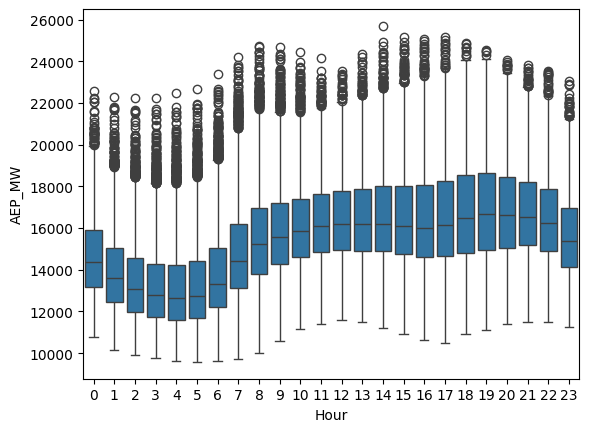

In [77]:
######################  TODO  ########################
sns.boxplot(x='Hour', y='AEP_MW', data=energyCsv)
######################  TODO  ########################

<h3>Energy Usage Over Hours</h3>
    we can see that around 15 to 21 when most people use lights and they are awake the power consumption is higher.

### Plot Energy Usage Over Months

<Axes: xlabel='Month', ylabel='AEP_MW'>

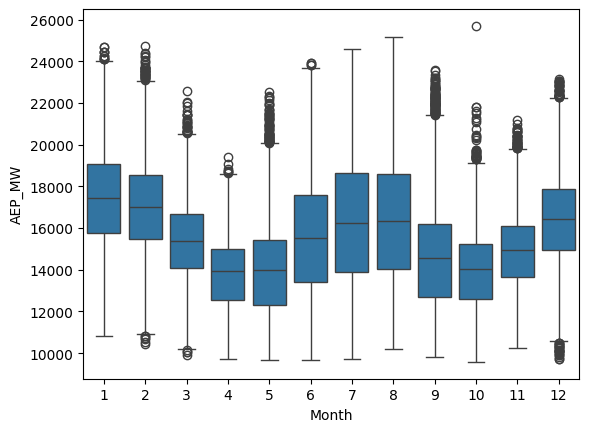

In [78]:
######################  TODO  ########################
sns.boxplot(x='Month', y='AEP_MW', data=energyCsv)
######################  TODO  ########################

<h3>Energy Usage Over Month</h3>
    we can see that in summer and late winters people use more energy because of a.c.

### Calculate Correlation Between Specific Hours and Energy Usage

    note: the aep mw ,year,month,hour are our 0,1,2,3s coloumn so we can access the correlation between each 2 row by their indices.

In [79]:
######################  TODO  ########################
filteredByHour = energyCsv[(energyCsv['Hour'] >= 4) & (energyCsv['Hour'] <= 13)]
print(correlation(filteredByHour)[0,3])
######################  TODO  ########################

0.4713789104396255


In [80]:
filteredByMonth2to4 = energyCsv[(energyCsv['Month'] >= 2) & (energyCsv['Month'] <= 4)]
filteredByMonth10to12 = energyCsv[(energyCsv['Month'] >= 10) & (energyCsv['Month'] <= 12)]
print('correlation for month between 2 to 4',correlation(filteredByMonth2to4)[0,2])
print('correlation for month between 10 to 12',correlation(filteredByMonth10to12)[0,2])

correlation for month between 2 to 4 -0.5582445746166723
correlation for month between 10 to 12 0.4738379625643042


### Analyze Correlation Between Specific Hours and Energy Usage

    as we can also observe in the boxplot of month the power consumption is decreasing in the month 2 to 4 so the correlation has become negative.
    but in the month 10-12 the power consumption is increasing so the correlation has become positive.

## Causal Effect

    note that our coloumns are le,ph,tvs so in the corr matrix the corr between le and ph would be the [0,1] and the corr between le and tv would be [0,2]

In [81]:
######################  TODO  ########################
file=pd.read_csv('data/TV_LE_Physician.csv')
corrMatrix=correlation(file)
print('the corr between LE and Phs is ',corrMatrix[0,1])
print('the corr between LE and TVs is ',corrMatrix[0,2])
######################  TODO  ########################

the corr between LE and Phs is  0.6288049366929702
the corr between LE and TVs is  0.02587481747720316


    the results indicate that the life expectency is a lot correlated to Physicians than the tvs .
    its obvious that the existance of Physicians is a vital element in any society to maintain the healthy life so its pretty relevant to say the number of Physicians have a direct relation to the life expectency.
    on the other hand the tv dont have much relevance to it.